In [45]:
from sklearn.datasets import load_breast_cancer
dataset=load_breast_cancer()

In [46]:
X=dataset.data
y=dataset.target

In [47]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [49]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [51]:
import torch
device=("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [52]:

X_traintensor=torch.tensor(X_train,dtype=torch.float32)
X_testtensor=torch.tensor(X_test,dtype=torch.float32)
y_testtensor=torch.tensor(y_test,dtype=torch.float32).view(-1,1)
y_traintensor=torch.tensor(y_train,dtype=torch.float32).view(-1,1)


In [53]:
from torch.utils.data import Dataset,DataLoader


In [54]:
class CustomDataset:
  def __init__(self,x,y):
    self.features=x
    self.labels=y
  def __len__(self):
    return len(self.features)
  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [55]:
traindataset=CustomDataset(X_traintensor,y_traintensor)
testdataset=CustomDataset(X_testtensor,y_testtensor)

In [56]:
traindataloader=DataLoader(traindataset,batch_size=32,shuffle=True)
testdataloader=DataLoader(testdataset,batch_size=32)

In [57]:
print(X_traintensor.shape)

torch.Size([455, 30])


In [58]:
import torch.nn as nn
import torch.optim
learningrate=0.01
epochs=100

In [59]:
class MyNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.data_network=nn.Sequential(
        nn.Linear(X_traintensor.shape[1],16),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        nn.Linear(16,8),
        nn.BatchNorm1d(8),
        nn.ReLU(),
        nn.Linear(8,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    return self.data_network(x)

In [60]:
model=MyNN().to(device)
loss_function=nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learningrate,weight_decay=1e-4)

In [61]:
for epoch in range(epochs):
  epochsum=0
  for X_batch,y_batch in traindataloader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    y_pred=model(X_batch)
    loss=loss_function(y_pred,y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epochsum+=loss.item()
  print(f'''the loss for epoch {epoch+1} is {epochsum/len(traindataloader)}''')


the loss for epoch 1 is 0.6820483366648357
the loss for epoch 2 is 0.6450140078862509
the loss for epoch 3 is 0.6128694534301757
the loss for epoch 4 is 0.5875530441602071
the loss for epoch 5 is 0.5668973008791606
the loss for epoch 6 is 0.542832092444102
the loss for epoch 7 is 0.5202663938204447
the loss for epoch 8 is 0.5059581061204275
the loss for epoch 9 is 0.48005526065826415
the loss for epoch 10 is 0.47291268507639567
the loss for epoch 11 is 0.4536417106787364
the loss for epoch 12 is 0.431964647769928
the loss for epoch 13 is 0.42833476265271503
the loss for epoch 14 is 0.4029675821463267
the loss for epoch 15 is 0.4039629598458608
the loss for epoch 16 is 0.3742647091547648
the loss for epoch 17 is 0.362474137544632
the loss for epoch 18 is 0.3507840077082316
the loss for epoch 19 is 0.33743385871251425
the loss for epoch 20 is 0.3216203848520915
the loss for epoch 21 is 0.3154135584831238
the loss for epoch 22 is 0.3051647027333578
the loss for epoch 23 is 0.2965940515200

In [62]:
model.eval()

MyNN(
  (data_network): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [63]:
correct=0
all_predictions = []
all_labels = []
all_probabilities = []
with torch.no_grad():
  for X_batch,y_batch in testdataloader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    output=model(X_batch)
    prediction=(output>0.5).float()
    correct+=(prediction==y_batch).sum().item()
    all_predictions.extend(prediction.cpu().numpy().flatten())
    all_labels.extend(y_batch.cpu().numpy().flatten())
    all_probabilities.extend(output.cpu().numpy().flatten())
  print(f'''accuracy is {correct/len(testdataset)}''')

accuracy is 0.9473684210526315


In [64]:
print("Precision :", precision_score(all_labels, all_predictions))
print("Recall    :", recall_score(all_labels, all_predictions))
print("F1 Score  :", f1_score(all_labels, all_predictions))
print("ROC AUC   :", roc_auc_score(all_labels, all_probabilities))

print("\nClassification Report\n")
print(classification_report(all_labels, all_predictions))

Precision : 0.9333333333333333
Recall    : 0.9859154929577465
F1 Score  : 0.958904109589041
ROC AUC   : 0.9754339993449067

Classification Report

              precision    recall  f1-score   support

         0.0       0.97      0.88      0.93        43
         1.0       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



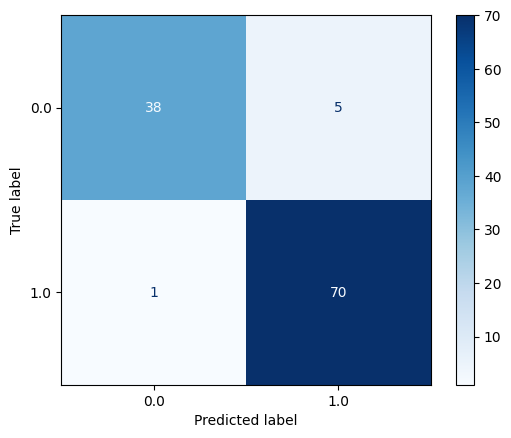

In [65]:
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    cmap="Blues"
)

plt.show()

In [66]:
correctt=0
with torch.no_grad():
  for X_batch,y_batch in traindataloader:
    X_batch=X_batch.to(device)
    y_batch=y_batch.to(device)
    output=model(X_batch)
    prediction=(output>0.5).float()
    correctt+=(prediction==y_batch).sum().item()
  print(f'''accuracy is {correctt/len(traindataset)}''')

accuracy is 0.9934065934065934
